# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [4]:
df = pd.read_csv(r"C:\Users\Diya\Downloads\data_for_predictions.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [5]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [6]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [8]:
# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [9]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Generate prediction probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [10]:
# Calculate performance metrics here!
# Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)

# Precision
precision = metrics.precision_score(y_test, y_pred)

# Recall
recall = metrics.recall_score(y_test, y_pred)

# F1 Score
f1 = metrics.f1_score(y_test, y_pred)

# ROC-AUC Score
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

print("\nConfusion Matrix")
print(cm)

Accuracy : 0.9041621029572837
Precision: 0.8333333333333334
Recall   : 0.0546448087431694
F1 Score : 0.10256410256410256
ROC AUC  : 0.6547511549245183

Confusion Matrix
[[3282    4]
 [ 346   20]]


                        Feature  Importance
11         margin_gross_pow_ele    0.053150
0                      cons_12m    0.053107
12           margin_net_pow_ele    0.051270
5       forecast_meter_rent_12m    0.047889
14                   net_margin    0.044449
3             forecast_cons_12m    0.040840
2               cons_last_month    0.037116
49                 months_activ    0.035051
15                      pow_max    0.033097
16  var_year_price_off_peak_var    0.031658


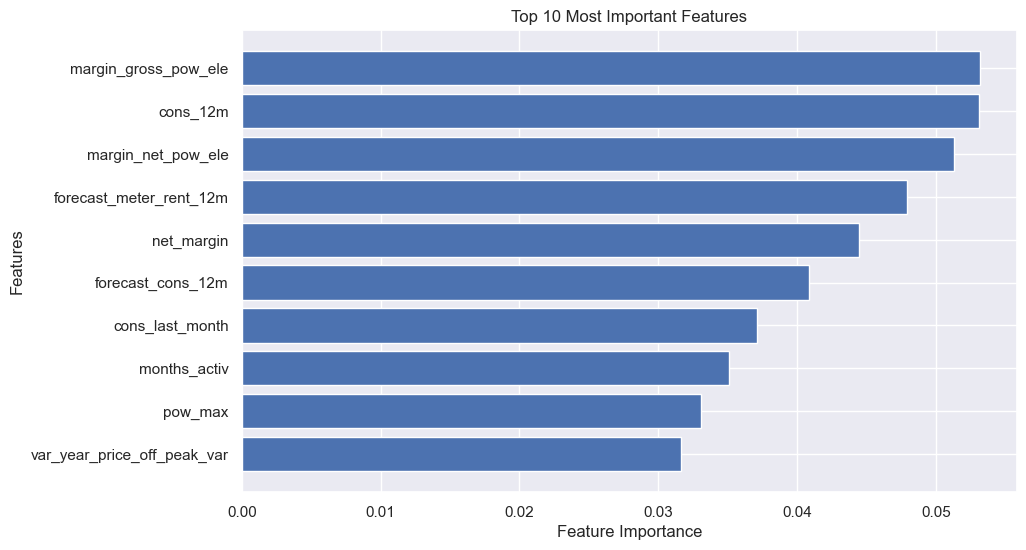

In [11]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with feature names and their importance scores
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

#### Accuracy, Precision, Recall, F1 Score, and ROC-AUC were selected to evaluate the Random Forest classifier because each metric provides different insights into model performance. While accuracy measures the overall proportion of correct predictions, it can be misleading for imbalanced datasets such as customer churn. Precision evaluates how many customers predicted to churn actually churned, reducing false positives. Recall measures the model's ability to correctly identify customers who actually churn, which is particularly important because missing potential churners can result in lost revenue. The F1 Score balances precision and recall, making it suitable for evaluating performance on imbalanced data. Finally, ROC-AUC measures the model's ability to distinguish between customers who churn and those who do not across different classification thresholds.

#### Do you think that the model performance is satisfactory?
The Random Forest model achieved an accuracy of approximately 90.4%, indicating that it correctly classified the majority of customers. The model also achieved a precision of 83.3%, meaning that when it predicted a customer would churn, the prediction was usually correct.

However, the recall was only 5.5%, which indicates that the model identified only a small proportion of customers who actually churned. Since the primary business objective is to identify customers at risk of leaving, this low recall suggests that many churning customers would not be detected.

Overall, the model provides a good starting point, but its performance is not fully satisfactory for a real-world customer retention strategy. Further improvements could include additional feature engineering, hyperparameter tuning, testing different machine learning algorithms, and applying more advanced techniques to handle class imbalance, such as SMOTE or optimized sampling methods.

#### Conclusion

The Random Forest classifier demonstrated strong overall accuracy and precision; however, its low recall indicates that it struggles to identify customers who are likely to churn. For a business focused on reducing customer churn, improving recall would be a priority, even if it results in a slight reduction in overall accuracy. Future work should focus on balancing the dataset and optimizing the model to better detect churning customers.